In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load data without assuming any header initially, so all rows are read as data
dados = pd.read_excel('/content/tarefa03.xlsx', header=None)

In [26]:
# Find the row where the first column contains 'Tipo de Ave' to set as the actual header
header_row_index = dados[dados.iloc[:, 0] == 'Tipo de Ave'].index[0]

# Get the actual column names from the identified header row
column_names = dados.iloc[header_row_index].tolist()

# Create the cleaned DataFrame starting from the row *after* the header row
dados_limpos = dados.iloc[header_row_index + 1:].copy()

# Assign the extracted column names to the cleaned DataFrame
dados_limpos.columns = column_names

# Reset index and drop the old index
dados_limpos = dados_limpos.reset_index(drop=True)

# Strip whitespace from all column names to ensure exact matches
dados_limpos.columns = dados_limpos.columns.str.strip()

# Rename 'Nº de Visitas' to 'Número de visitas' for consistency with plotting
dados_limpos = dados_limpos.rename(columns={
    'Nº de Visitas': 'Número de visitas'
})

# Convert relevant columns to numeric types, handling potential errors
dados_limpos['Número de visitas'] = pd.to_numeric(dados_limpos['Número de visitas'], errors='coerce')
# Ensure the distance column uses its original name from the Excel file headers
dados_limpos['Distancia do Fragmento Florestal (m)'] = pd.to_numeric(dados_limpos['Distancia do Fragmento Florestal (m)'], errors='coerce')

# Convert 'Tipo de Ave' to string type to avoid potential issues in plotting categorical data
dados_limpos['Tipo de Ave'] = dados_limpos['Tipo de Ave'].astype(str)

# Display the cleaned data info
print(dados_limpos.info())
print(dados_limpos.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Tipo de Ave                           18 non-null     object 
 1   Microhabitat                          18 non-null     object 
 2   Número de visitas                     18 non-null     int64  
 3   Distancia do Fragmento Florestal (m)  18 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 708.0+ bytes
None
        Tipo de Ave Microhabitat  Número de visitas  \
0  Sabiá-laranjeira  Mata Nativa                 24   
1        Asa Branca  Mata Nativa                 19   
2         Cambacica  Mata Nativa                 28   
3         Bem-te-vi  Mata Nativa                 22   
4           Avoante  Mata Nativa                 31   

   Distancia do Fragmento Florestal (m)  
0                                  12.5  
1        

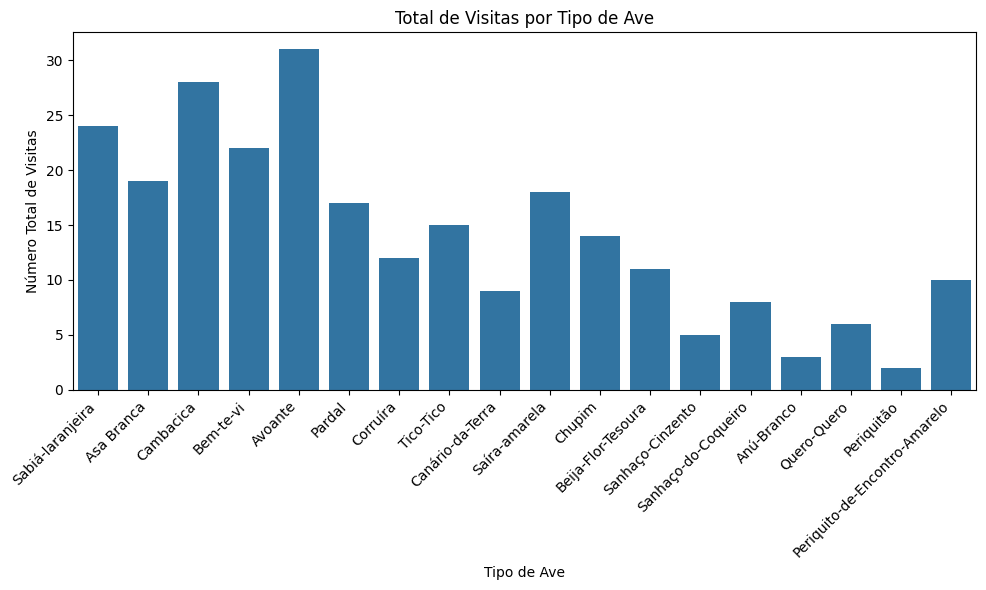

In [22]:
# 1. Bar chart: 'tipo de ave' and 'numero de visitas'
plt.figure(figsize=(10, 6))
sns.barplot(x='Tipo de Ave', y='Número de visitas', data=dados_limpos, estimator=sum, errorbar=None)
plt.title('Total de Visitas por Tipo de Ave')
plt.xlabel('Tipo de Ave')
plt.ylabel('Número Total de Visitas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

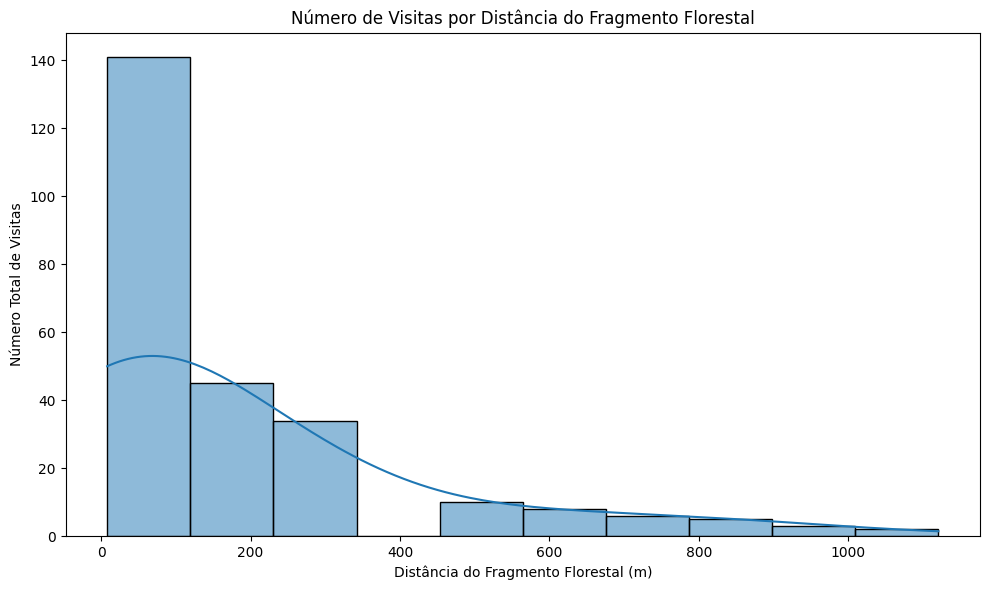

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=dados_limpos,
    x='Distancia do Fragmento Florestal (m)',
    weights='Número de visitas', # Use 'Número de visitas' as weights
    kde=True,
    bins=10
)
plt.title('Número de Visitas por Distância do Fragmento Florestal')
plt.xlabel('Distância do Fragmento Florestal (m)')
plt.ylabel('Número Total de Visitas') # Updated ylabel
plt.tight_layout()
plt.show()

In [34]:
fig = px.scatter(
    dados_limpos,
    x='Distancia do Fragmento Florestal (m)',
    y='Número de visitas',
    color='Microhabitat',
    title='Número de Visitas vs. Distância do Fragmento Florestal por Microhabitat',
    labels={
        'Distancia do Fragmento Florestal (m)': 'Distância do Fragmento Florestal (m)',
        'Número de visitas': 'Número de Visitas'
    }
)
fig.show()